## *Implementasi Logistic Regression dengan Python*

# Data Preparation

In [1]:
import pandas as pd #Membaca dan mengolah dataset
import numpy as np #Melakukan operasi numerik
import matplotlib.pyplot as plt #Membuat visualisasi data dalam bentuk grafik
import seaborn as sns #Membuat visualisasi statistik dengan tampilan yang lebih informatif

In [2]:
# Membaca dataset
df = pd.read_csv("data_SNA.csv")
df.head(10) #menampilkan lima baris pertama dari dataset

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


In [3]:
#Membaca informasai dan Memeriksa Missing Value
df.info() #Untuk mengetahui jumlah data, tipe data setiap variabel, serta memastikan tidak terdapat nilai kosong
df.isnull().sum() #memeriksa bahwa tidak terdapat data yang hilang (missing value)

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          100 non-null    int64
 1   Gender           100 non-null    str  
 2   Age              100 non-null    int64
 3   EstimatedSalary  100 non-null    int64
 4   Purchased        100 non-null    int64
dtypes: int64(4), str(1)
memory usage: 4.0 KB


User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [4]:
# Memilih variabel yang digunakan
df = df[['Age', 'EstimatedSalary', 'Purchased']]

# Menampilkan lima data pertama
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


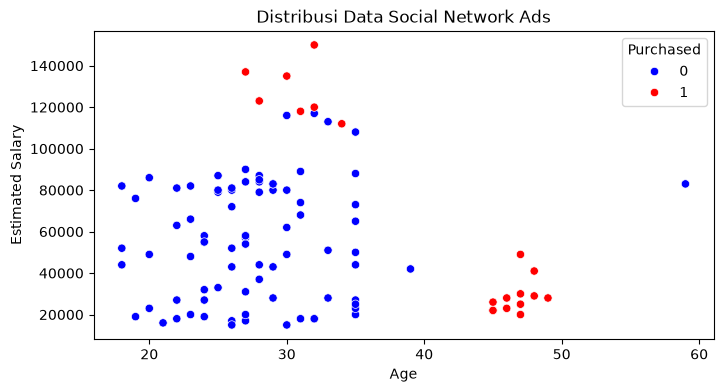

In [5]:
# visualisasi Awal (scatter plot)
# menggunakan scatter plot untuk melihat persebaran data berdasarkan kelas Purchased.

plt.figure(figsize=(8,4))

sns.scatterplot(
    data=df,
    x='Age',
    y='EstimatedSalary',
    hue='Purchased',
    palette=['blue','red']
)

plt.title('Distribusi Data Social Network Ads')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend(title='Purchased')
plt.show()

## Pemisahan Fitur dan Target (Feature–Target Splitting)

In [6]:
# Menentukan variabel fitur (X)
X = df[['Age', 'EstimatedSalary']]
#Menampilkan Hasil Pemisahan
display(X.head()) # Menampilkan Feature (X)

# Menentukan variabel target (y)
y = df['Purchased']
display(y.head()) # Menampilkan Target (y)

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000


0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

## Pembagian Data Latih dan Data Uji (Train–Test Split)

In [7]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    X,                  #Variabel masukan yang akan digunakan model
    y,                  #Variabel yang akan diprediksi
    test_size=0.20,     #Menentukan bahwa 20% data digunakan sebagai data uji, sedangkan 80% sisanya menjadi data latih.
    random_state=42,     #Menetapkan nilai acak agar hasil pembagian data selalu sama setiap kali program dijalankan (reproducible).
    stratify=y          #Memastikan proporsi kelas pada data latih dan data uji akan tetap seimbang mengikuti distribusi pada dataset asli
)


# Melihat Ukuran Data
# Untuk memastikan proses pembagian data berhasil dilakukan, jumlah data pada masing-masing dataset dapat ditampilkan menggunakan atribut .shape.

print("Jumlah data latih :", X_train.shape)
print("Jumlah data uji   :", X_test.shape)

print("Jumlah target latih :", y_train.shape)
print("Jumlah target uji   :", y_test.shape)

Jumlah data latih : (80, 2)
Jumlah data uji   : (20, 2)
Jumlah target latih : (80,)
Jumlah target uji   : (20,)


## Normalisasi Data (Feature Scaling)

In [8]:
from sklearn.preprocessing import StandardScaler

# Membuat objek StandardScaler
scaler = StandardScaler() 

# Normalisasi data latih
# fit_transform() digunakan untuk menghitung nilai rata-rata (mean) dan standar deviasi dari setiap fitur dan menggunakan nilai tersebut untuk melakukan normalisasi pada data latih
X_train = scaler.fit_transform(X_train)
# Menampilkan hasil normalisasi data latih (beberapa baris pertama)
display(X_train[:5])

# Normalisasi data uji
X_test = scaler.transform(X_test)
# Menampilkan hasil normalisasi data uji (beberapa baris pertama)
display(X_test[:5])

array([[-0.84949434,  0.26326489],
       [-1.43535251,  0.754488  ],
       [ 0.32222199, -0.19725678],
       [-0.49797944,  0.72378655],
       [ 3.36868446,  0.78518944]])

array([[-0.96666598, -0.93409145],
       [-0.84949434,  0.754488  ],
       [-0.49797944, -1.30250878],
       [-0.02929291,  2.38166456],
       [-0.96666598,  0.17116055]])

## Pelatihan Model Logistic Regression (Model Training)

In [9]:
from sklearn.linear_model import LogisticRegression

# Membuat model Logistic Regression
model = LogisticRegression(random_state=42)

# Melatih model menggunakan data latih
model.fit(X_train, y_train)

# Menampilkan Parameter Model
print("Koefisien :", model.coef_) # Koefisien (weights) menunjukkan besarnya pengaruh masing-masing fitur terhadap prediksi model

print("Intercept :", model.intercept_) # Intercept (bias) merupakan nilai awal yang digunakan model sebelum mempertimbangkan pengaruh setiap fitur

Koefisien : [[1.91589982 0.66340207]]
Intercept : [-2.32260525]


# Prediksi Model (Prediction)

#### Melakukan Prediksi Kelas

In [ ]:
# Melakukan prediksi pada data uji
y_pred = model.predict(X_test)

hasil_prediksi = pd.DataFrame({
    'Actual': y_test.values,
    'Prediction': y_pred
})

hasil_prediksi.head(10)

,Actual,Prediction
0,0,0
1,0,0
2,0,0
3,1,0
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


#### Melihat Probabilitas Prediksi

In [11]:
# Menampilkan probabilitas prediksi
probability = model.predict_proba(X_test)

probability[:10]

array([[0.9917913 , 0.0082087 ],
       [0.96921988, 0.03078012],
       [0.9843386 , 0.0156614 ],
       [0.68970196, 0.31029804],
       [0.98306166, 0.01693834],
       [0.97262807, 0.02737193],
       [0.88272913, 0.11727087],
       [0.43362067, 0.56637933],
       [0.8891729 , 0.1108271 ],
       [0.90602811, 0.09397189]])

#### Visualisasi Decision Boundary

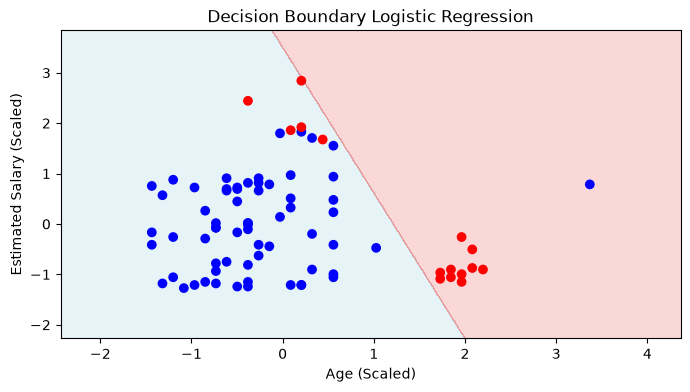

In [12]:
from matplotlib.colors import ListedColormap
import numpy as np

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:,0].min()-1,
              stop=X_set[:,0].max()+1,
              step=0.01),
    np.arange(start=X_set[:,1].min()-1,
              stop=X_set[:,1].max()+1,
              step=0.01)
)

plt.figure(figsize=(8,4))

plt.contourf(
    X1,
    X2,
    model.predict(
        np.array([X1.ravel(), X2.ravel()]).T
    ).reshape(X1.shape),
    alpha=0.3,
    cmap=ListedColormap(('lightblue','lightcoral'))
)

plt.scatter(
    X_set[:,0],
    X_set[:,1],
    c=y_set,
    cmap=ListedColormap(('blue','red'))
)

plt.title('Decision Boundary Logistic Regression')
plt.xlabel('Age (Scaled)')
plt.ylabel('Estimated Salary (Scaled)')
plt.show()

## Evaluasi Performa Model (Model Evaluation)

#### Menghitung Accuracy

In [13]:
from sklearn.metrics import accuracy_score

# Menghitung akurasi model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9


#### Confusion Matrix

In [14]:
from sklearn.metrics import confusion_matrix

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[16  0]
 [ 2  2]]


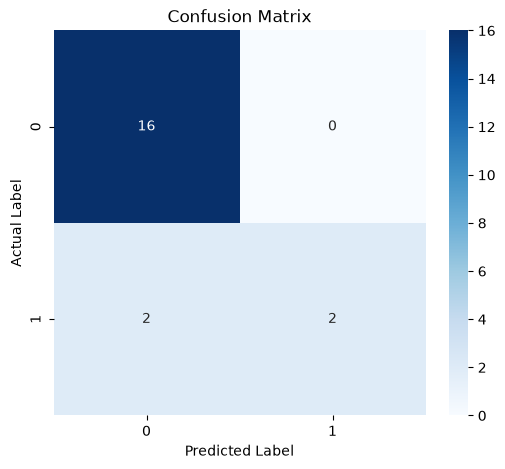

In [15]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

#### Clasification Report
Untuk memperoleh informasi evaluasi yang lebih lengkap
- Precision mengukur ketepatan model ketika memprediksi suatu kelas.
- Recall mengukur kemampuan model dalam menemukan seluruh data pada suatu kelas.
- F1-Score rata-rata harmonis antara Precision dan Recall.
- Support jumlah data pada masing-masing kelas.


In [16]:
from sklearn.metrics import classification_report

# Menampilkan classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        16
           1       1.00      0.50      0.67         4

    accuracy                           0.90        20
   macro avg       0.94      0.75      0.80        20
weighted avg       0.91      0.90      0.89        20

